In [1]:
import os

if os.getcwd() == '/home/jorge/tokenPred/babylm_10m/test_eval/evaluation-pipeline-2025/evaluation_pipeline/sentence_zero_shot':
    os.chdir('/home/jorge/tokenPred/babylm_10m/test_eval/evaluation-pipeline-2025/') 
else:
    os.chdir('/home/jorge/tokenPred/babylm_10m/test_eval/evaluation-pipeline-2025/evaluation_pipeline/sentence_zero_shot')

In [2]:
os.environ["CUDA_VISIBLE_DEVICES"] = "7"  # To use GPUs with IDs 0 and 1

In [3]:
#we load in the  libraries we will use for evaluation
import torch
from scipy import stats
from transformers import AutoModelForCausalLM, AutoTokenizer
import matplotlib.pyplot as plt
import json
import re
from pathlib import Path
import numpy as np
# Run the repo's exact pipeline codepaths inside the notebook (faithful reproduction)
from types import SimpleNamespace
from evaluation_pipeline.sentence_zero_shot.dataset import get_dataloader
# from dataset import get_dataloader
from evaluation_pipeline.sentence_zero_shot.compute_results import compute_results
# from compute_results import compute_results
# from evaluation_pipeline.sentence_zero_shot.run import process_results, create_evaluation_report
from evaluation_pipeline.sentence_zero_shot.run import process_results, create_evaluation_report
import io
from contextlib import redirect_stdout, redirect_stderr


In [4]:
# Path to the EWOK datasets
ewok_fast_path = "/home/jorge/tokenPred/babylm_10m/test_eval/evaluation-pipeline-2025/evaluation_data/fast_eval/ewok_fast"
ewok_filtered_path = "/home/jorge/tokenPred/babylm_10m/test_eval/evaluation-pipeline-2025/evaluation_data/full_eval/ewok_filtered"

def load_ewok_dataset(data_path, domain=None):
    """Load EWOK dataset from local files"""
    dataset = []
    
    if domain:
        # Load specific domain
        file_path = Path(data_path) / f"{domain}.jsonl"
        if file_path.exists():
            with open(file_path, 'r') as f:
                for line in f:
                    dataset.append(json.loads(line.strip()))
    else:
        # Load all domains
        for file_path in Path(data_path).glob("*.jsonl"):
            with open(file_path, 'r') as f:
                for line in f:
                    dataset.append(json.loads(line.strip()))
    
    return dataset

# Example usage:
# Load all domains from fast evaluation
ewok_fast_data = load_ewok_dataset(ewok_fast_path)
print(f"Fast eval dataset: {len(ewok_fast_data)} examples")



Fast eval dataset: 1100 examples


We will first evaluate the models on the default babylm paths

In [5]:

def capture_output(fn, *args, **kwargs):
    buf = io.StringIO()
    with redirect_stdout(buf), redirect_stderr(buf):
        result = fn(*args, **kwargs)
    return result, buf.getvalue()

# usage
def f(n):
    for i in range(n):
        print(i)
    return n*n
def extract_accuracies(report: str, *, lowercase_keys: bool = True) -> dict[str, float]:
    """
    Parse a report string and return { category_or_domain: accuracy_float }.

    - Captures any line shaped like:  <label>: <number>
    - Skips section headers (### ...), 'TEMPERATURE: ...', ellipses, and blanks.
    - Leaves keys as-is unless lowercase_keys=True (default), which lowercases them.

    Example keys captured:
      'material-properties', 'social-interactions', 'direct', 'indirect',
      'antonym', 'variable swap', etc.
    """
    accuracies: dict[str, float] = {}
    for raw in report.splitlines():
        line = raw.strip()
        if not line or line.startswith("###") or line.startswith("..."):
            continue
        if line.upper().startswith("TEMPERATURE:"):
            continue

        m = re.match(r"^([A-Za-z][A-Za-z0-9 _\-]+?)\s*:\s*([0-9]+(?:\.[0-9]+)?)\s*$", line)
        if not m:
            # This also skips the final "AVERAGE ACCURACY" number (no colon)
            continue

        key, val = m.group(1).strip(), float(m.group(2))
        if lowercase_keys:
            key = key.lower()
        accuracies[key] = val

    return accuracies


In [6]:
def plot_scores_with_ci(scores_dict, scores_dict_2=None, model_1_label='Model 1', model_2_label='Model 2',Title= 'Standard Mean Scores Across Domains, P(T_i|C_i) > P(T_j|C_i)', confidence_level=0.95):
    """
    Calculates the mean and confidence interval for model scores in different domains
    and plots them as a bar chart with error bars. Can optionally plot a second model's scores
    side-by-side for comparison.

    Args:
        scores_dict (dict): A dictionary for the first model where keys are domain names (str)
                            and values are lists of scores (float or int).
        scores_dict_2 (dict, optional): An optional dictionary for the second model with the same format.
        model_1_label (str): The label for the first model's data on the plot.
        model_2_label (str): The label for the second model's data on the plot.
        confidence_level (float): The desired confidence level for the interval (e.g., 0.95 for 95%).
    """
    domains = list(scores_dict.keys())
    
    # --- Calculate stats for Model 1 ---
    means_1 = []
    ci_errors_1 = []
    for domain in domains:
        scores = scores_dict.get(domain, [])
        n = len(scores)
        mean = np.mean(scores) if n > 0 else 0
        means_1.append(mean)

        if n > 1:
            sem = stats.sem(scores)
            t_critical = stats.t.ppf((1 + confidence_level) / 2., n - 1)
            ci_error = t_critical * sem
            ci_errors_1.append(ci_error)
        else:
            ci_errors_1.append(0)

    # --- Plotting Setup ---
    x = np.arange(len(domains))  # the label locations
    width = 0.4  # the width of the bars

    fig, ax = plt.subplots(figsize=(15, 8))

    # --- Plot Bars ---
    if scores_dict_2 is not None:
        # Adjust width and positions for side-by-side bars
        width = 0.35
        rects1 = ax.bar(x - width/2, means_1, width, yerr=ci_errors_1, label=model_1_label, capsize=4, color='skyblue', ecolor='darkgray')
        
        # Calculate stats for Model 2
        means_2 = []
        ci_errors_2 = []
        for domain in domains:
            scores = scores_dict_2.get(domain, [])
            n = len(scores)
            mean = np.mean(scores) if n > 0 else 0
            means_2.append(mean)

            if n > 1:
                sem = stats.sem(scores)
                t_critical = stats.t.ppf((1 + confidence_level) / 2., n - 1)
                ci_error = t_critical * sem
                ci_errors_2.append(ci_error)
            else:
                ci_errors_2.append(0)
        
        rects2 = ax.bar(x + width/2, means_2, width, yerr=ci_errors_2, label=model_2_label, capsize=4, color='lightcoral', ecolor='darkgray')
    else:
        # Plot a single set of bars if only one dictionary is provided
        rects1 = ax.bar(x, means_1, width, yerr=ci_errors_1, label=model_1_label, capsize=5, color='skyblue', ecolor='darkgray')

    #we add horizontal line at y= 50 percent to denote chance level
    ax.axhline(y=50, color='red', linestyle='--', label='Chance Level (50%)')
    # --- Formatting the plot ---
    ax.set_ylabel('Mean Score', fontsize=12)
    ax.set_title(Title, fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(domains, rotation=90)
    ax.set_yticks(np.arange(0, 111, 10))
    ax.grid(axis='y', linestyle='-', alpha=0.8)
    ax.legend()
    
    # Ensure everything fits within the figure
    plt.tight_layout()
    
    # Display the plot
    plt.show()


In [7]:


model_paths = []
model_paths.append('Jorgeis1/babygpt-10m-trial_run_Oc6th_BTSZ_16_sid19')
model_paths.append('Jorgeis1/babygpt-10m-trial_run_Oc6th_BTSZ_16_sid58')
model_paths.append('Jorgeis1/babygpt-10m-trial_run_Oc6th_BTSZ_16_sid121')
model_paths.append('Jorgeis1/babygpt-10m-trial_run_Oc6th_BTSZ_16_sid123')
model_paths.append('Jorgeis1/babygpt-10m-trial_run_Oc6th_BTSZ_16_sid79')

# model_path = 'openai-community/gpt2-xl'
baseline_accuracies = {}

for model_path in model_paths:
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(model_path)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.device

    args = SimpleNamespace(
        data_path=Path("/home/jorge/tokenPred/babylm_10m/test_eval/evaluation-pipeline-2025/evaluation_data/fast_eval/ewok_fast"),
        output_dir=Path("/tmp"),
        task="ewok",
        model_path_or_name=model_path,
        backend="causal",
        min_temperature=1.0,
        max_temperature=None,
        temperature_interval=0.05,
        batch_size=64,
        non_causal_batch_size=64,
        full_sentence_scores=False,
        save_predictions=False,
        revision_name="main",
    )

    model_name = model_path 


    dataloader = get_dataloader(args)
    temperatures = [1.0]
    results, _ = compute_results(args, model, dataloader, temperatures)
    accuracies, average_accuracies = process_results(args, results)

    # create_evaluation_report(1.0, average_accuracies[1.0], accuracies[1.0])
    #we try capturing the output
    val, out = capture_output(create_evaluation_report, 1.0, average_accuracies[1.0], accuracies[1.0])
    print(out)
    ewok_accuracies = extract_accuracies(out)
    print(ewok_accuracies)
    for k, v in ewok_accuracies.items():
        baseline_accuracies[f"{k}"] = baseline_accuracies.get(f"{k}", [])
        baseline_accuracies[f"{k}"].append(v)
    baseline_accuracies
    

100%|██████████| 18/18 [00:01<00:00,  9.86it/s]


TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 46.00
social-interactions: 52.00
social-relations: 50.00
spatial-relations: 41.00
quantitative-properties: 54.00
physical-dynamics: 45.00
agent-properties: 52.00
social-properties: 56.00
physical-relations: 57.00
physical-interactions: 43.00
material-dynamics: 45.00

### CONTEXT_TYPE ACCURACY
direct: 49.69
indirect: 48.77

### CONTEXT_CONTRAST ACCURACY
antonym: 47.67
negation: 60.53
material: 44.60
variable swap: 51.18
other: 56.79
active-passive: 66.67
number: 50.00
variable_swap: 50.00

### TARGET_CONTRAST ACCURACY
concept swap: 48.91
variable swap: 50.22

### AVERAGE ACCURACY
49.18


{'material-properties': 46.0, 'social-interactions': 52.0, 'social-relations': 50.0, 'spatial-relations': 41.0, 'quantitative-properties': 54.0, 'physical-dynamics': 45.0, 'agent-properties': 52.0, 'social-properties': 56.0, 'physical-relations': 57.0, 'physical-interactions': 43.0, 'material-dynamics': 45.0, 'direct': 49.69, 'indirect': 48.77, 'a

100%|██████████| 18/18 [00:01<00:00, 11.22it/s]


TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 46.00
social-interactions: 55.00
social-relations: 48.00
spatial-relations: 41.00
quantitative-properties: 50.00
physical-dynamics: 48.00
agent-properties: 54.00
social-properties: 54.00
physical-relations: 53.00
physical-interactions: 44.00
material-dynamics: 43.00

### CONTEXT_TYPE ACCURACY
direct: 50.71
indirect: 47.13

### CONTEXT_CONTRAST ACCURACY
antonym: 47.33
negation: 60.53
material: 43.17
variable swap: 52.61
other: 55.56
active-passive: 66.67
number: 40.91
variable_swap: 33.33

### TARGET_CONTRAST ACCURACY
concept swap: 47.88
variable swap: 51.98

### AVERAGE ACCURACY
48.73


{'material-properties': 46.0, 'social-interactions': 55.0, 'social-relations': 48.0, 'spatial-relations': 41.0, 'quantitative-properties': 50.0, 'physical-dynamics': 48.0, 'agent-properties': 54.0, 'social-properties': 54.0, 'physical-relations': 53.0, 'physical-interactions': 44.0, 'material-dynamics': 43.0, 'direct': 50.71, 'indirect': 47.13, 'a

100%|██████████| 18/18 [00:01<00:00, 11.30it/s]


TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 46.00
social-interactions: 49.00
social-relations: 44.00
spatial-relations: 39.00
quantitative-properties: 59.00
physical-dynamics: 47.00
agent-properties: 47.00
social-properties: 53.00
physical-relations: 59.00
physical-interactions: 49.00
material-dynamics: 41.00

### CONTEXT_TYPE ACCURACY
direct: 48.88
indirect: 48.11

### CONTEXT_CONTRAST ACCURACY
antonym: 46.67
negation: 60.53
material: 41.73
variable swap: 50.24
other: 56.79
active-passive: 66.67
number: 63.64
variable_swap: 66.67

### TARGET_CONTRAST ACCURACY
concept swap: 48.57
variable swap: 48.02

### AVERAGE ACCURACY
48.45


{'material-properties': 46.0, 'social-interactions': 49.0, 'social-relations': 44.0, 'spatial-relations': 39.0, 'quantitative-properties': 59.0, 'physical-dynamics': 47.0, 'agent-properties': 47.0, 'social-properties': 53.0, 'physical-relations': 59.0, 'physical-interactions': 49.0, 'material-dynamics': 41.0, 'direct': 48.88, 'indirect': 48.11, 'a

100%|██████████| 18/18 [00:01<00:00, 12.05it/s]


TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 46.00
social-interactions: 53.00
social-relations: 51.00
spatial-relations: 48.00
quantitative-properties: 45.00
physical-dynamics: 42.00
agent-properties: 50.00
social-properties: 56.00
physical-relations: 53.00
physical-interactions: 42.00
material-dynamics: 45.00

### CONTEXT_TYPE ACCURACY
direct: 49.90
indirect: 46.96

### CONTEXT_CONTRAST ACCURACY
antonym: 46.83
negation: 60.53
material: 44.60
variable swap: 51.66
other: 51.85
active-passive: 100.00
number: 36.36
variable_swap: 50.00

### TARGET_CONTRAST ACCURACY
concept swap: 47.65
variable swap: 50.66

### AVERAGE ACCURACY
48.27


{'material-properties': 46.0, 'social-interactions': 53.0, 'social-relations': 51.0, 'spatial-relations': 48.0, 'quantitative-properties': 45.0, 'physical-dynamics': 42.0, 'agent-properties': 50.0, 'social-properties': 56.0, 'physical-relations': 53.0, 'physical-interactions': 42.0, 'material-dynamics': 45.0, 'direct': 49.9, 'indirect': 46.96, 'a

100%|██████████| 18/18 [00:01<00:00, 12.15it/s]

TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 48.00
social-interactions: 54.00
social-relations: 55.00
spatial-relations: 45.00
quantitative-properties: 52.00
physical-dynamics: 46.00
agent-properties: 48.00
social-properties: 55.00
physical-relations: 60.00
physical-interactions: 48.00
material-dynamics: 43.00

### CONTEXT_TYPE ACCURACY
direct: 50.71
indirect: 50.08

### CONTEXT_CONTRAST ACCURACY
antonym: 49.17
negation: 60.53
material: 43.88
variable swap: 55.45
other: 54.32
active-passive: 100.00
number: 40.91
variable_swap: 33.33

### TARGET_CONTRAST ACCURACY
concept swap: 49.60
variable swap: 53.30

### AVERAGE ACCURACY
50.36


{'material-properties': 48.0, 'social-interactions': 54.0, 'social-relations': 55.0, 'spatial-relations': 45.0, 'quantitative-properties': 52.0, 'physical-dynamics': 46.0, 'agent-properties': 48.0, 'social-properties': 55.0, 'physical-relations': 60.0, 'physical-interactions': 48.0, 'material-dynamics': 43.0, 'direct': 50.71, 'indirect': 50.08, '

In [ ]:
# #we now compare with custom model
# #the first is the custom dataset based off gemini
# finetuned_model_path = ['Jorgeis1/babygpt-10m-ft_CustomGemini_16_121_epochs2','Jorgeis1/babygpt-10m-ft_CustomGemini_16_154_epochs2','Jorgeis1/babygpt-10m-ft_CustomGemini_16_104_epochs2','Jorgeis1/babygpt-10m-ft_CustomGemini_16_123_epochs2','Jorgeis1/babygpt-10m-ft_CustomGemini_16_263_epochs2','Jorgeis1/babygpt-10m-ft_CustomGemini_16_727_epochs2']
finetuned_model_path = ['Jorgeis1/babygpt-10m-ft_CustomSpat_16_727_epochs4','Jorgeis1/babygpt-10m-ft_CustomSpat_16_124_epochs4','Jorgeis1/babygpt-10m-ft_CustomSpat_16_123_epochs4']
finetuned_accuracies = {}
for model_path in finetuned_model_path:
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(model_path)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.device

    args = SimpleNamespace(
        data_path=Path("/home/jorge/tokenPred/babylm_10m/test_eval/evaluation-pipeline-2025/evaluation_data/fast_eval/ewok_fast"),
        output_dir=Path("/tmp"),
        task="ewok",
        model_path_or_name=model_path,
        backend="causal",
        min_temperature=1.0,
        max_temperature=None,
        temperature_interval=0.05,
        batch_size=64,
        non_causal_batch_size=64,
        full_sentence_scores=False,
        save_predictions=False,
        revision_name="main",
    )

    model_name = model_path 
    print(model_path)

    dataloader = get_dataloader(args)
    temperatures = [1.0]
    results, _ = compute_results(args, model, dataloader, temperatures)
    accuracies, average_accuracies = process_results(args, results)

    # create_evaluation_report(1.0, average_accuracies[1.0], accuracies[1.0])
    #we try capturing the output
    val, out = capture_output(create_evaluation_report, 1.0, average_accuracies[1.0], accuracies[1.0])
    print(out)
    ewok_accuracies = extract_accuracies(out)
    # print(ewok_accuracies)
    for k, v in ewok_accuracies.items():
        finetuned_accuracies[f"{k}"] = finetuned_accuracies.get(f"{k}", [])
        finetuned_accuracies[f"{k}"].append( v)
        print(v)
    
    


Jorgeis1/babygpt-10m-ft_CustomSpat_16_727_epochs4


100%|██████████| 18/18 [00:01<00:00, 12.02it/s]


TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 50.00
social-interactions: 54.00
social-relations: 47.00
spatial-relations: 47.00
quantitative-properties: 51.00
physical-dynamics: 51.00
agent-properties: 57.00
social-properties: 53.00
physical-relations: 60.00
physical-interactions: 43.00
material-dynamics: 54.00

### CONTEXT_TYPE ACCURACY
direct: 50.92
indirect: 52.05

### CONTEXT_CONTRAST ACCURACY
antonym: 50.00
negation: 60.53
material: 52.52
variable swap: 50.71
other: 58.02
active-passive: 100.00
number: 50.00
variable_swap: 50.00

### TARGET_CONTRAST ACCURACY
concept swap: 51.32
variable swap: 52.42

### AVERAGE ACCURACY
51.55


50.0
54.0
47.0
47.0
51.0
51.0
57.0
53.0
60.0
43.0
54.0
50.92
52.05
50.0
60.53
52.52
52.42
58.02
100.0
50.0
50.0
51.32
Jorgeis1/babygpt-10m-ft_CustomSpat_16_124_epochs4


 56%|█████▌    | 10/18 [00:00<00:00, 11.52it/s]

In [ ]:
#we now compare with custom model
# data_mixed_model_path = ['Jorgeis1/babygpt-10m-trial_run_Oct_24_CustomGemini_16_121_epochs10']
data_mixed_model_path = ['Jorgeis1/babygpt-10m-trial_run_Dec_CustomAG_16_58_epochs10','Jorgeis1/babygpt-10m-trial_run_Dec_CustomAG_16_19_epochs10','Jorgeis1/babygpt-10m-trial_run_Dec_CustomAG_16_79_epochs10','Jorgeis1/babygpt-10m-trial_run_Dec_CustomAG_16_123_epochs10','Jorgeis1/babygpt-10m-trial_run_Dec_CustomAG_16_121_epochs10']
data_mixed_accuracies = {}
for model_path in data_mixed_model_path:
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(model_path)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.device

    args = SimpleNamespace(
        data_path=Path("/home/jorge/tokenPred/babylm_10m/test_eval/evaluation-pipeline-2025/evaluation_data/fast_eval/ewok_fast"),
        output_dir=Path("/tmp"),
        task="ewok",
        model_path_or_name=model_path,
        backend="causal",
        min_temperature=1.0,
        max_temperature=None,
        temperature_interval=0.05,
        batch_size=64,
        non_causal_batch_size=64,
        full_sentence_scores=False,
        save_predictions=False,
        revision_name="main",
    )

    model_name = model_path 
    print(model_path)

    dataloader = get_dataloader(args)
    temperatures = [1.0]
    results, _ = compute_results(args, model, dataloader, temperatures)
    accuracies, average_accuracies = process_results(args, results)

    # create_evaluation_report(1.0, average_accuracies[1.0], accuracies[1.0])
    #we try capturing the output
    val, out = capture_output(create_evaluation_report, 1.0, average_accuracies[1.0], accuracies[1.0])
    print(out)
    ewok_accuracies = extract_accuracies(out)
    # print(ewok_accuracies)
    for k, v in ewok_accuracies.items():
        data_mixed_accuracies[f"{k}"] = data_mixed_accuracies.get(f"{k}", [])
        data_mixed_accuracies[f"{k}"].append( v)
        print(v)

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Jorgeis1/babygpt-10m-trial_run_Dec_CustomAG_16_58_epochs10


100%|██████████| 18/18 [00:01<00:00, 12.10it/s]


TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 44.00
social-interactions: 49.00
social-relations: 54.00
spatial-relations: 46.00
quantitative-properties: 54.00
physical-dynamics: 53.00
agent-properties: 54.00
social-properties: 57.00
physical-relations: 51.00
physical-interactions: 44.00
material-dynamics: 49.00

### CONTEXT_TYPE ACCURACY
direct: 51.73
indirect: 49.43

### CONTEXT_CONTRAST ACCURACY
antonym: 48.33
negation: 60.53
material: 47.48
variable swap: 53.08
other: 58.02
active-passive: 100.00
number: 50.00
variable_swap: 50.00

### TARGET_CONTRAST ACCURACY
concept swap: 49.71
variable swap: 53.30

### AVERAGE ACCURACY
50.45


44.0
49.0
54.0
46.0
54.0
53.0
54.0
57.0
51.0
44.0
49.0
51.73
49.43
48.33
60.53
47.48
53.3
58.02
100.0
50.0
50.0
49.71


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

...

TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 53.00
social-interactions: 53.00
social-relations: 46.00
spatial-relations: 47.00
quantitative-properties: 52.00
physical-dynamics: 53.00
agent-properties: 62.00
social-properties: 56.00
physical-relations: 50.00
physical-interactions: 44.00
material-dynamics: 51.00

### CONTEXT_TYPE ACCURACY
direct: 52.34
indirect: 50.90

### CONTEXT_CONTRAST ACCURACY
antonym: 50.33
negation: 60.53
material: 49.64
variable swap: 53.55
other: 54.32
active-passive: 33.33
number: 54.55
variable_swap: 50.00

### TARGET_CONTRAST ACCURACY
concept swap: 51.55
variable swap: 51.54

### AVERAGE ACCURACY
51.55


53.0
53.0
46.0
47.0
52.0
53.0
62.0
56.0
50.0
44.0
51.0
52.34
50.9
50.33
60.53
49.64
51.54
54.32
33.33
54.55
50.0
51.55


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Jorgeis1/babygpt-10m-trial_run_Dec_CustomAG_16_121_epochs10


100%|██████████| 18/18 [00:01<00:00, 12.05it/s]

TEMPERATURE: 1.00

### UID ACCURACY
material-properties: 50.00
social-interactions: 48.00
social-relations: 46.00
spatial-relations: 39.00
quantitative-properties: 52.00
physical-dynamics: 52.00
agent-properties: 56.00
social-properties: 53.00
physical-relations: 52.00
physical-interactions: 39.00
material-dynamics: 45.00

### CONTEXT_TYPE ACCURACY
direct: 48.47
indirect: 48.28

### CONTEXT_CONTRAST ACCURACY
antonym: 48.33
negation: 55.26
material: 46.04
variable swap: 47.39
other: 55.56
active-passive: 66.67
number: 31.82
variable_swap: 50.00

### TARGET_CONTRAST ACCURACY
concept swap: 48.22
variable swap: 48.90

### AVERAGE ACCURACY
48.36


50.0
48.0
46.0
39.0
52.0
52.0
56.0
53.0
52.0
39.0
45.0
48.47
48.28
48.33
55.26
46.04
48.9
55.56
66.67
31.82
50.0
48.22


In [ ]:
finetuned_accuracies

{'material-properties': [50.0, 49.0, 51.0],
 'social-interactions': [54.0, 55.0, 56.0],
 'social-relations': [47.0, 52.0, 45.0],
 'spatial-relations': [47.0, 50.0, 48.0],
 'quantitative-properties': [51.0, 56.0, 55.0],
 'physical-dynamics': [51.0, 52.0, 54.0],
 'agent-properties': [57.0, 57.0, 52.0],
 'social-properties': [53.0, 54.0, 55.0],
 'physical-relations': [60.0, 57.0, 58.0],
 'physical-interactions': [43.0, 44.0, 43.0],
 'material-dynamics': [54.0, 54.0, 55.0],
 'direct': [50.92, 52.14, 51.73],
 'indirect': [52.05, 53.2, 52.22],
 'antonym': [50.0, 52.33, 51.67],
 'negation': [60.53, 60.53, 60.53],
 'material': [52.52, 50.36, 52.52],
 'variable swap': [52.42, 53.74, 50.66],
 'other': [58.02, 59.26, 56.79],
 'active-passive': [100.0, 100.0, 66.67],
 'number': [50.0, 54.55, 54.55],
 'variable_swap': [50.0, 50.0, 50.0],
 'concept swap': [51.32, 52.46, 52.35]}

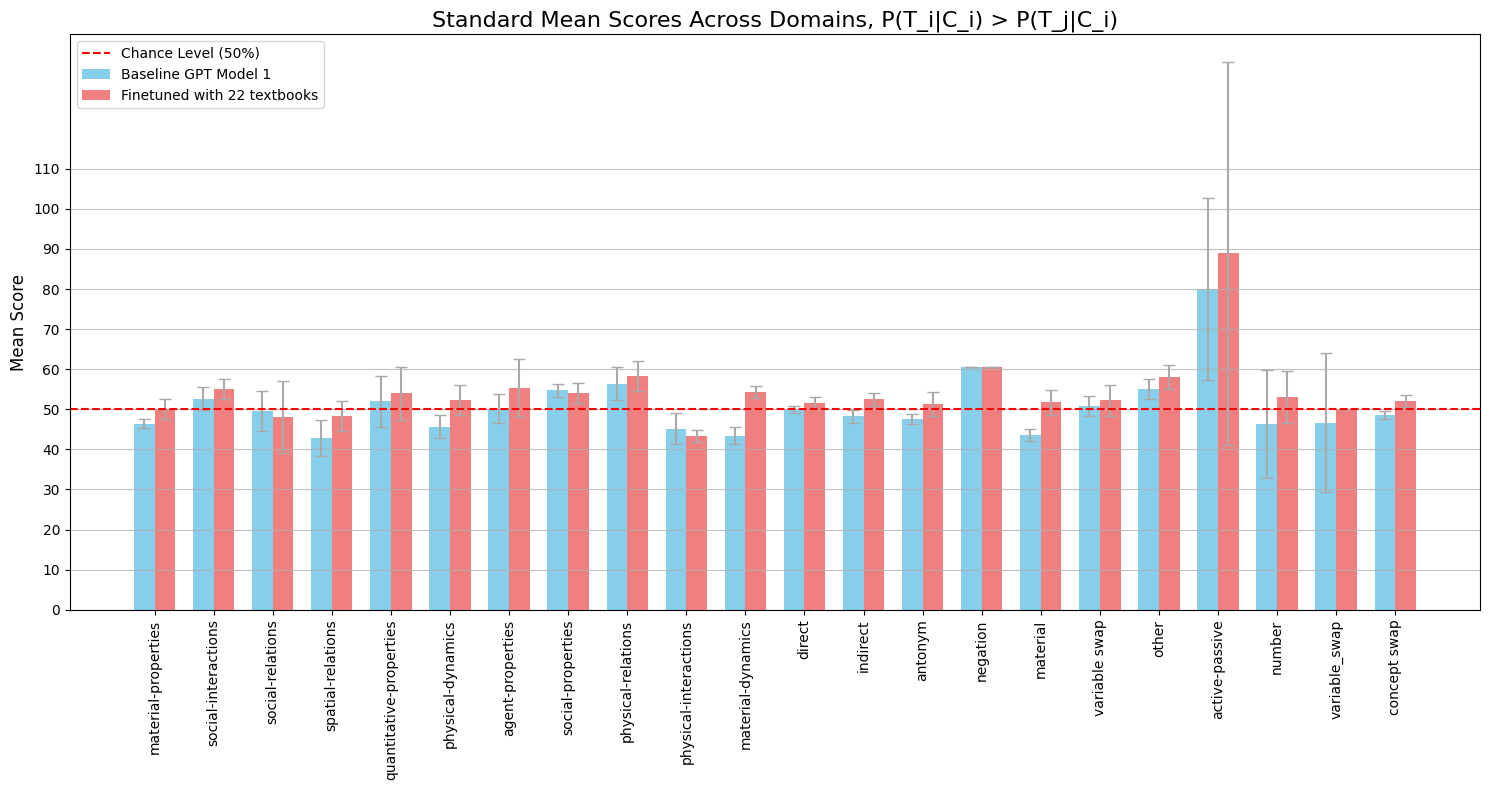

In [ ]:
#we plot the charts with CLI for a single model
plot_scores_with_ci(baseline_accuracies,finetuned_accuracies, model_1_label='Baseline GPT Model 1',model_2_label='Finetuned with 22 textbooks', confidence_level=0.95)


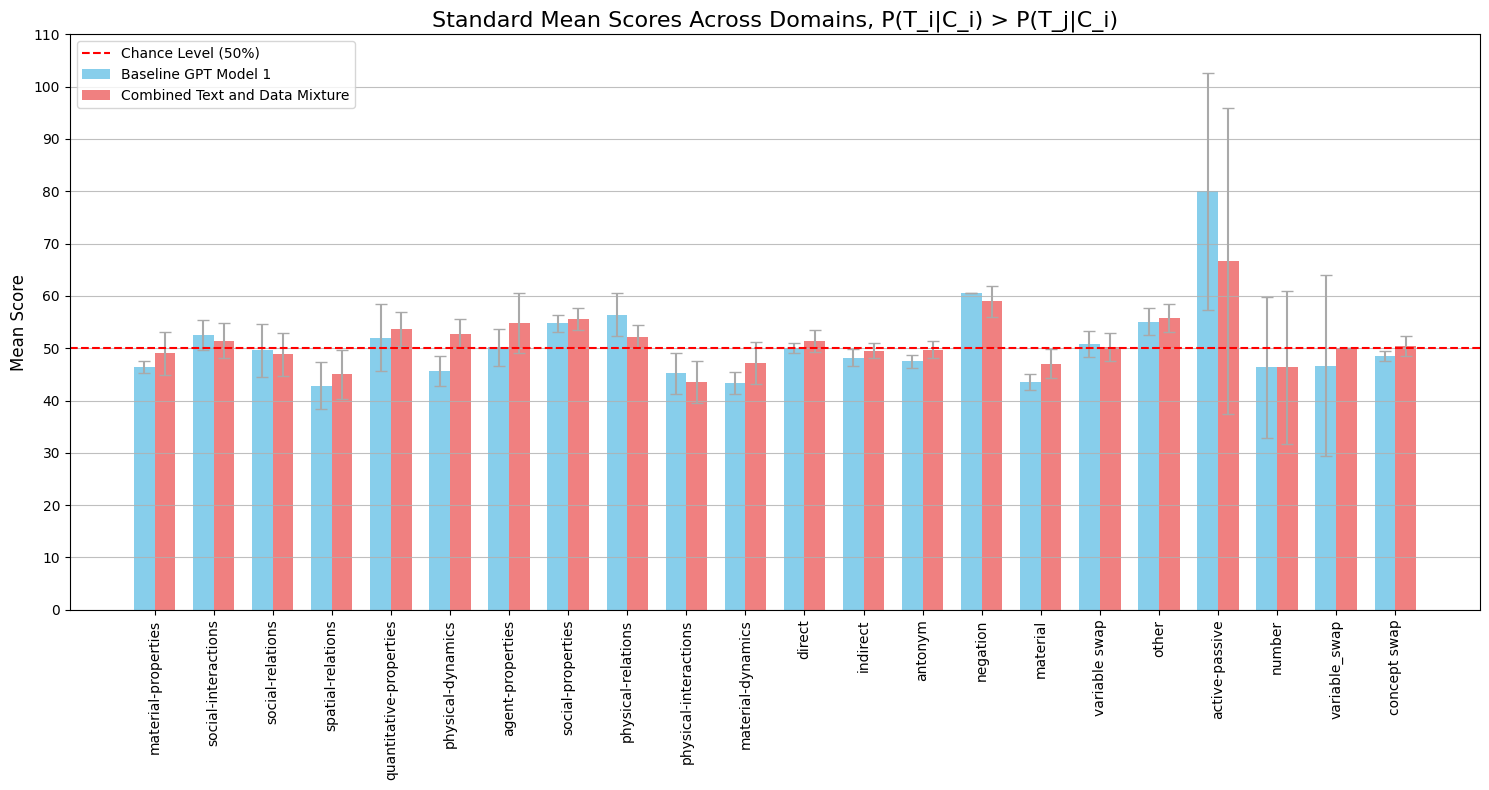

In [ ]:
# plot_scores_with_ci(baseline_accuracies,finetuned_accuracies, model_1_label='Baseline GPT Model 1',model_2_label='Finetuned with 22 textbooks', confidence_level=0.95)
plot_scores_with_ci(baseline_accuracies,data_mixed_accuracies, model_1_label='Baseline GPT Model 1',model_2_label='Combined Text and Data Mixture', confidence_level=0.95)

In [ ]:
#we compute P(T|C_i) - P(T|C_j)
model_path = 'Jorgeis1/babygpt-10m-trial_run_Dec_CustomAG_16_123_epochs10'
tokenizer = AutoTokenizer.from_pretrained(model_path) # Or your fine-tuned model
model = AutoModelForCausalLM.from_pretrained(model_path) # Or your fine-tuned model\
model.to(device)
context_1 = 'Jesse applied pressure to the balloon. It remained intact.'
target_1 = 'The balloon is sturdy.'
target_2 = 'The balloon is fragile.'
text = context_1 + " " + target_2
# print(tokenizer.bos_token)
def compute_log_likelihood(model, tokenizer, text,mean=False):
    # Prepend the BOS token to the text
    input_text = text

    # Tokenize the input
    inputs = tokenizer(input_text, add_special_tokens=False, return_tensors="pt")
    input_ids = inputs.input_ids
    length_of_text = len(input_ids[0])
    attn_mask = inputs.attention_mask
    bos_token_id = tokenizer.bos_token_id
    # bos_token_id = 236
    print(tokenizer.decode([236]))
    input_ids = torch.cat([torch.tensor([[bos_token_id]]), input_ids], dim=1)
    input_ids = input_ids.to(model.device)
    # print(tokenizer.decode(input_ids[0]))
    # input_ids = torch.cat([torch.tensor([tokenizer.bos_token_id]), input_ids[0]], dim=0)
    attn_mask = torch.cat([torch.tensor([1]), attn_mask[0]], dim=0)
    attn_mask = attn_mask.to(model.device)
    with torch.no_grad():
    # The model's output contains logits
        outputs = model(input_ids=input_ids, attention_mask=attn_mask)
        logits = outputs['logits']
        # print( 'logits shape ',logits.shape)
    # we remove the last token from the logits and the input ids, since it's not relevant for the log likelihood
    logits = logits[:,:-1,:]
    log_probs = torch.log_softmax(logits, dim=-1)
    # print('input_ids shape: ', input_ids.shape)
    # print('log_probs shape',log_probs.shape)
    # we remove the first token from the input ids, since it's the BOS token
    input_ids = input_ids[:,1:]
    #we remove the first token from the attention mask, since it's the BOS token
    attn_mask = attn_mask[1:]
    token_logprobs = log_probs.gather(dim=-1, index=input_ids.unsqueeze(-1)).squeeze(-1)
    # print('token_logprobs shape',token_logprobs.shape)
    total_log_prob = torch.sum(token_logprobs*attn_mask)
    # print(f"Log-likelihood with BOS: {total_log_prob.item()}")
    if mean == True:
        return total_log_prob.item()/length_of_text
    else:
        return total_log_prob.item()
ll_1 = compute_log_likelihood(model, tokenizer, context_1 + " " + target_1)
ll_2 = compute_log_likelihood(model, tokenizer, context_1 + " " + target_2)
print(f"P(T|C_i) - P(T|C_j) = {ll_1 - ll_2}")

�
�
P(T|C_i) - P(T|C_j) = 0.31017303466796875


In [ ]:
def per_token_log_likelihood(model, tokenizer, input_text,context = None):
    # Prepend the BOS token to the text

    # Tokenize the input
    inputs = tokenizer(input_text, add_special_tokens=False, return_tensors="pt")
    input_ids = inputs.input_ids
    if context is not None:
        #we want to add the context sentence ids to the input ids (which are the target sentence ids)
        #rather than just join the sentences
        # to ensure tokens are processed correctly 
        context_ids = tokenizer(context, add_special_tokens=False, return_tensors="pt").input_ids
        input_ids = torch.cat([context_ids, input_ids], dim=1)
        attn_mask = torch.cat([torch.ones(context_ids.shape[1]), inputs.attention_mask[0]], dim=0).to(device)
    #length_of_text = len(input_ids[0])
    attn_mask = inputs.attention_mask
    bos_token_id = tokenizer.bos_token_id
    input_ids = torch.cat([torch.tensor([[bos_token_id]]), input_ids], dim=1).to(device)
    attn_mask = torch.cat([torch.tensor([1]), attn_mask[0]], dim=0).to(device)
    with torch.no_grad():
    # The model's output contains logits
        outputs = model(input_ids=input_ids, attention_mask=attn_mask)
        logits = outputs['logits']
    # we remove the last token from the logits and the input ids, since it's not relevant for the log likelihood
    logits = logits[:,:-1,:]
    log_probs = torch.log_softmax(logits, dim=-1)
    # we remove the first token from the input ids, since it's the BOS token
    input_ids = input_ids[:,1:]
    #we remove the first token from the attention mask, since it's the BOS token
    attn_mask = attn_mask[1:]
    token_logprobs = log_probs.gather(dim=-1, index=input_ids.unsqueeze(-1)).squeeze(-1)
    #target sentence logprobs
    return token_logprobs
# compute_log_likelihood(model, tokenizer, 'The balloon is sturdy.',mean=False)
per_token_log_likelihood(model, tokenizer, 'The soup is flavorful as heck.', context= 'The chef added salt to the soup. It tasted bland.')

tensor([[ -6.5573, -10.2067,  -9.9467, -10.8097,  -0.9463,  -1.5909,  -5.1940,
          -2.2308,  -2.6002,  -9.7047, -13.2186,  -3.7981, -11.9438,  -4.5480,
          -2.3673, -17.3681,  -4.6667, -15.8728,  -2.4839]], device='cuda:0')

In [ ]:
def per_token_conditional_log_likelihood(model, tokenizer, context, target):
    text = context + " " + target
    context_token_length = len(tokenizer.encode(context,add_special_tokens=False))
    # print('context_token_length', context_token_length)
    # print(len(tokenizer.encode(text,add_special_tokens=False)))
    # print('target_token_length', target_token_length)
    return per_token_log_likelihood(model, tokenizer, target, context=context)[:,context_token_length:]
ptcll = per_token_conditional_log_likelihood(model, tokenizer, 'The chef added salt to the soup. it tasted bland.', 'The soup is flavorful as heck.')
ptcll

tensor([[-12.3131,  -4.5062,  -2.3052, -17.4592,  -4.7231, -16.0393,  -2.6371]],
       device='cuda:0')

In [ ]:
import torch
from typing import List, Optional

def per_token_log_likelihood(model, tokenizer, 
                             input_texts: List[str], 
                             contexts: Optional[List[str]] = None):
    """
    Calculates per-token log-likelihoods for a batch of texts, 
    optionally conditioned on a batch of contexts.
    """
    
    context_token_length = 0
    # --- 1. Tokenize inputs (handling context if provided) ---
    if contexts is not None:
        # Tokenize contexts and targets separately, with padding
        context_inputs = tokenizer(contexts, add_special_tokens=False, return_tensors="pt", padding=True)
        target_inputs = tokenizer(input_texts, add_special_tokens=False, return_tensors="pt", padding=True)
        
        context_ids = context_inputs.input_ids
        target_ids = target_inputs.input_ids
        
        # Get the padded length of the context, which we'll need for slicing later
        context_token_length = context_ids.shape[1]
        
        # Concatenate IDs: [B, seq_len_ctx] + [B, seq_len_tgt] -> [B, seq_len_ctx + seq_len_tgt]
        input_ids = torch.cat([context_ids, target_ids], dim=1)
        
        # Concatenate masks
        context_mask = context_inputs.attention_mask
        target_mask = target_inputs.attention_mask
        attn_mask = torch.cat([context_mask, target_mask], dim=1)
        
    else:
        # No context, just tokenize input_texts
        inputs = tokenizer(input_texts, add_special_tokens=False, return_tensors="pt", padding=True)
        input_ids = inputs.input_ids
        attn_mask = inputs.attention_mask

    # --- 2. Prepend BOS Token (Batched) ---
    batch_size = input_ids.shape[0]
    bos_token_id = tokenizer.bos_token_id
    
    # Create BOS tensors for the batch
    bos_ids = torch.full((batch_size, 1), bos_token_id, dtype=torch.long).to(device)
    bos_mask = torch.ones((batch_size, 1), dtype=torch.long).to(device)
    
    # Move main tensors to device
    input_ids = input_ids.to(device)
    attn_mask = attn_mask.to(device)

    # Prepend BOS
    input_ids = torch.cat([bos_ids, input_ids], dim=1)
    attn_mask = torch.cat([bos_mask, attn_mask], dim=1)

    # --- 3. Model Forward Pass ---
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attn_mask)
        logits = outputs['logits']

    # --- 4. Calculate Log Probs ---
    
    # Shift logits to align: logit[i] predicts token[i+1]
    # shape: [B, seq_len, vocab_size]
    logits = logits[:, :-1, :] 
    log_probs = torch.log_softmax(logits, dim=-1)

    # Shift input_ids to align: token[i+1] is the target for logit[i]
    # shape: [B, seq_len]
    input_ids = input_ids[:, 1:] 
    
    # Gather the log-probabilities for the actual tokens
    # input_ids.unsqueeze(-1) shape: [B, seq_len, 1]
    # token_logprobs shape: [B, seq_len, 1] -> [B, seq_len]
    token_logprobs = log_probs.gather(dim=-1, index=input_ids.unsqueeze(-1)).squeeze(-1)
    
    # --- 5. Masking ---
    # We must use the shifted 2D attention mask to zero out logprobs for padding tokens
    
    # Shift attention mask (to align with shifted input_ids)
    # This fixes the bug in the original code (attn_mask[1:])
    attn_mask = attn_mask[:, 1:] 
    
    # Zero out logprobs where attention mask is 0 (i.e., padding)
    token_logprobs = token_logprobs * attn_mask

    # Return both the logprobs and the length of the context part
    return token_logprobs, context_token_length


def per_token_conditional_log_likelihood(model, tokenizer, 
                                         contexts: List[str], 
                                         targets: List[str]):
    """
    Calculates per-token log-likelihoods for a batch of target texts, 
    conditioned on a batch of context texts.
    """
    
    # Call the batched function, passing targets as input_texts and contexts as contexts
    # It returns the logprobs for the *entire* sequence and the padded length of the context
    token_logprobs, context_len = per_token_log_likelihood(
        model, 
        tokenizer, 
        targets, 
        contexts=contexts
    )
    
    # Slice the result tensor to get *only* the log-probabilities for the target tokens.
    # The target tokens start right after the padded context tokens.
    return token_logprobs[:, context_len:]
# Example usage:
contexts = [
    'Jesse applied pressure to the balloon. It remained intact.',
    'The chef added salt to the soup. It tasted bland.'
]
targets = [
    'The balloon is fragile.',
    'The soup is flavorful as heck.'
]
ptcll_batch = per_token_conditional_log_likelihood(model, tokenizer, contexts, targets)


In [ ]:
#we define a function that compute the conditional log likelihoods in batches
# of size batch_size, and returns the list of log likelihoods
def batch_per_token_conditional_log_likelihood(model, tokenizer, contexts: List[str], targets: List[str], batch_size: int = 8):
    all_log_likelihoods = []
    for i in range(0, len(targets), batch_size):
        batch_contexts = contexts[i:i+batch_size]
        batch_targets = targets[i:i+batch_size]
        batch_log_likelihoods = per_token_conditional_log_likelihood(model, tokenizer, batch_contexts, batch_targets)
        all_log_likelihoods.extend(batch_log_likelihoods.cpu().numpy())
    return all_log_likelihoods


In [ ]:
import pandas as pd
from pathlib import Path

SRC = Path("/home/jorge/tokenPred/babylm_10m/test_eval/evaluation-pipeline-2025/evaluation_data/fast_eval/ewok_fast")          # adjust path if needed

ewok_df = pd.concat(
    [
        pd.read_json(fp, lines=True, encoding="utf-8")
        #   .assign(file=fp.name, category=fp.stem)  # metadata
        for fp in SRC.glob("*.jsonl")              # use rglob("*.jsonl") if nested
    ],
    ignore_index=True,
    sort=False,    # keep union of columns
)

# optional niceties
ewok_df = ewok_df.convert_dtypes()
ewok_df

,Domain,ConceptA,ConceptB,ContextType,ContextDiff,TargetDiff,Context1,Context2,Target1,Target2
0,material-properties,fragile,sturdy,direct,antonym,concept swap,Jesse applied pressure to the balloon. It rema...,Jesse applied pressure to the balloon. It broke.,The balloon is sturdy.,The balloon is fragile.
1,material-properties,transparent,opaque,direct,negation,concept swap,Chao cannot see through the wheel.,Chao can see through the wheel.,The wheel is opaque.,The wheel is transparent.
2,material-properties,soft,hard,indirect,material,concept swap,The bin is made of jelly.,The bin is made of glass.,The bin is soft.,The bin is hard.
3,material-properties,soft,hard,indirect,material,concept swap,The balloon is made of terracotta.,The balloon is made of fabric.,The surface of the balloon is hard.,The surface of the balloon is soft.
4,material-properties,heavy,light,direct,antonym,concept swap,The balloon weighs a lot.,The balloon weighs little.,The balloon is heavy.,The balloon is light.
...,...,...,...,...,...,...,...,...,...,...
1095,material-dynamics,drape,stir,indirect,material,concept swap,Ali sees the propane.,Ali sees the twill.,Ali stirs it.,Ali drapes it.
1096,material-dynamics,drape,stir,direct,material,concept swap,Chao sees something that is liquid.,Chao sees something that is fabric.,Chao stirs it.,Chao drapes it.
1097,material-dynamics,squeeze,stir,indirect,material,concept swap,Mohammed sees the nitrogen.,Mohammed sees the play-doh.,Mohammed stirs it.,Mohammed squeezes it.
1098,material-dynamics,break,drip,indirect,material,concept swap,Chao sees the water.,Chao sees the feather.,It drips.,It breaks.


In [ ]:
ewok_df[ewok_df['Domain'] == 'agent-properties']

,Domain,ConceptA,ConceptB,ContextType,ContextDiff,TargetDiff,Context1,Context2,Target1,Target2
600,agent-properties,believe,doubt,indirect,variable swap,concept swap,Yan successfully lied to Chao that the wheel w...,Chao successfully lied to Yan that the wheel w...,Chao doubts that the wheel is in the shop.,Chao believes that the wheel is in the shop.
601,agent-properties,make more effort,make less effort,indirect,variable swap,concept swap,Jesse hates playing volleyball less than playi...,Jesse hates playing tennis less than playing v...,Jesse makes more effort to play volleyball tha...,Jesse makes less effort to play volleyball tha...
602,agent-properties,make more effort,make less effort,indirect,variable swap,variable swap,Jesse likes Alex more than Mohammed.,Jesse likes Mohammed more than Alex.,Jesse makes more effort to interact with Alex ...,Jesse makes more effort to interact with Moham...
603,agent-properties,make more effort,make less effort,indirect,variable swap,variable swap,Mohammed hates Carmen less than Li.,Mohammed hates Li less than Carmen.,Mohammed makes less effort to interact with Li...,Mohammed makes less effort to interact with Ca...
604,agent-properties,make more effort,make less effort,indirect,variable swap,variable swap,Chao is more intent on playing pool than on pl...,Chao is more intent on playing football than o...,Chao makes less effort to play football than t...,Chao makes less effort to play pool than to pl...
...,...,...,...,...,...,...,...,...,...,...
695,agent-properties,believe,doubt,indirect,negation,concept swap,Ali is in the bakery. Ali sees the rock inside.,Ali is in the bakery. Ali doesn't see the rock...,Ali believes that the rock is in the bakery.,Ali doubts that the rock is in the bakery.
696,agent-properties,intend,not intend,indirect,other,concept swap,Mohammed is moving past the volleyball.,Mohammed is moving toward the volleyball.,Mohammed does not intend to get the volleyball.,Mohammed intends to get the volleyball.
697,agent-properties,make more effort,make less effort,indirect,antonym,concept swap,Chao is more intent on playing football than o...,Chao is less intent on playing football than o...,Chao makes more effort to play football than t...,Chao makes less effort to play football than t...
698,agent-properties,make more effort,make less effort,indirect,variable swap,concept swap,Chao is more intent on meeting Yan than meetin...,Chao is more intent on meeting Ali than meetin...,Chao makes more effort to interact with Yan th...,Chao makes less effort to interact with Yan th...


In [ ]:
def add_ptcll_column(df, model, tokenizer, batch_size=16):
    #we want to compute P(T|C_i) - P(T|C_j) for a batch of contexts and targets on the ewok dataset
    # we take the log probability difference of Target1 given Context1  and Target1 given Context2
    context_1 = df['Context1'].tolist()
    context_2 = df['Context2'].tolist()
    target_1 = df['Target1'].tolist()
    target_2 = df['Target2'].tolist()
    #compute conditional log likelihoods in batches
    ll_context1_target1 = batch_per_token_conditional_log_likelihood(model, tokenizer, context_1, target_1, batch_size=batch_size)
    sum_ll_context1_target1 = [np.sum(ll) for ll in ll_context1_target1]
    ll_context2_target1 = batch_per_token_conditional_log_likelihood(model, tokenizer, context_2, target_1, batch_size=batch_size)
    sum_ll_context2_target1 = [np.sum(ll) for ll in ll_context2_target1]
    ll_diff_target1 = [a - b for a, b in zip(sum_ll_context1_target1, sum_ll_context2_target1)]
    #we make a copy of the dataframe
    new_df = df.copy()
    new_df['P(T1|C1) - P(T1|C2)'] = ll_diff_target1

    ll_context1_target2 = batch_per_token_conditional_log_likelihood(model, tokenizer, context_1, target_2, batch_size=batch_size)
    sum_ll_context1_target2 = [np.sum(ll) for ll in ll_context1_target2]

    ll_context2_target2 = batch_per_token_conditional_log_likelihood(model, tokenizer, context_2, target_2, batch_size=batch_size)
    sum_ll_context2_target2 = [np.sum(ll) for ll in ll_context2_target2]
    #we care to see how much correct context increases the log likelihood of the target
    ll_diff_target2 = [b-a  for a, b in zip(sum_ll_context1_target2, sum_ll_context2_target2)]
    new_df['P(T2|C2) - P(T2|C1)'] = ll_diff_target2
    return new_df

In [ ]:
#we make a function that takes in a copy of the ewok dataframe, 
# and we adds a column with the per token conditional log likelihoods
def add_ptcll_column(df, model, tokenizer, batch_size=16):
    #we want to compute P(T|C_i) - P(T|C_j) for a batch of contexts and targets on the ewok dataset
    # we take the log probability difference of Target1 given Context1  and Target1 given Context2
    context_1 = df['Context1'].tolist()
    context_2 = df['Context2'].tolist()
    target_1 = df['Target1'].tolist()
    target_2 = df['Target2'].tolist()
    #compute conditional log likelihoods in batches
    ll_context1_target1 = batch_per_token_conditional_log_likelihood(model, tokenizer, context_1, target_1, batch_size=batch_size)
    sum_ll_context1_target1 = [np.sum(ll) for ll in ll_context1_target1]
    ll_context2_target1 = batch_per_token_conditional_log_likelihood(model, tokenizer, context_2, target_1, batch_size=batch_size)
    sum_ll_context2_target1 = [np.sum(ll) for ll in ll_context2_target1]
    ll_diff_target1 = [a - b for a, b in zip(sum_ll_context1_target1, sum_ll_context2_target1)]
    #we make a copy of the dataframe
    new_df = df.copy()
    new_df['P(T1|C1) - P(T1|C2)'] = ll_diff_target1

    ll_context1_target2 = batch_per_token_conditional_log_likelihood(model, tokenizer, context_1, target_2, batch_size=batch_size)
    sum_ll_context1_target2 = [np.sum(ll) for ll in ll_context1_target2]

    ll_context2_target2 = batch_per_token_conditional_log_likelihood(model, tokenizer, context_2, target_2, batch_size=batch_size)
    sum_ll_context2_target2 = [np.sum(ll) for ll in ll_context2_target2]
    #we care to see how much correct context increases the log likelihood of the target
    ll_diff_target2 = [b-a  for a, b in zip(sum_ll_context1_target2, sum_ll_context2_target2)]
    new_df['P(T2|C2) - P(T2|C1)'] = ll_diff_target2
    return new_df

In [ ]:
#we want to compute P(T|C_i) - P(T|C_j) for a batch of contexts and targets on the ewok dataset
# we take the log probability difference of Target1 given Context1  and Target1 given Context2
context_1 = ewok_df['Context1'].tolist()
context_2 = ewok_df['Context2'].tolist()
target_1 = ewok_df['Target1'].tolist()
target_2 = ewok_df['Target2'].tolist()


In [ ]:
# ll_context1_target1 = batch_per_token_conditional_log_likelihood(model, tokenizer, context_1, target_1, batch_size=16)
# sum_ll_context1_target1 = [np.sum(ll) for ll in ll_context1_target1]

# ll_context2_target1 = batch_per_token_conditional_log_likelihood(model, tokenizer, context_2, target_1, batch_size=16)
# sum_ll_context2_target1 = [np.sum(ll) for ll in ll_context2_target1]
# ll_diff_target1 = [a - b for a, b in zip(sum_ll_context1_target1, sum_ll_context2_target1)]
# ewok_df['P(T1|C1) - P(T1|C2)'] = ll_diff_target1

# ll_context1_target2 = batch_per_token_conditional_log_likelihood(model, tokenizer, context_1, target_2, batch_size=16)
# sum_ll_context1_target2 = [np.sum(ll) for ll in ll_context1_target2]

# ll_context2_target2 = batch_per_token_conditional_log_likelihood(model, tokenizer, context_2, target_2, batch_size=16)
# sum_ll_context2_target2 = [np.sum(ll) for ll in ll_context2_target2]
# #we care to see how much correct context increases the log likelihood of the target
# ll_diff_target2 = [b-a  for a, b in zip(sum_ll_context1_target2, sum_ll_context2_target2)]
# ewok_df['P(T2|C2) - P(T2|C1)'] = ll_diff_target2
# ewok_df


In [ ]:
# we now write a function that computes per-domain and overall accuracies
def report_domain(df):
    domain_accuracies = {}
    domains = df['Domain'].unique()
    for domain in domains:
        domain_df = df[df['Domain'] == domain]
        correct = 0
        total = len(domain_df)
        for index, row in domain_df.iterrows():
            if row['P(T1|C1) - P(T1|C2)'] > 0 and row['P(T2|C2) - P(T2|C1)'] > 0:
                correct += 1
        accuracy = correct / total * 100
        domain_accuracies[domain] = accuracy
    overall_correct = 0
    overall_total = len(df)
    for index, row in df.iterrows():
        if row['P(T1|C1) - P(T1|C2)'] > 0 and row['P(T2|C2) - P(T2|C1)'] > 0:
            overall_correct += 1
    overall_accuracy = overall_correct / overall_total * 100
    domain_accuracies['overall'] = overall_accuracy
    return domain_accuracies
def report_domain(df):
    #we generate a report of the average log likelihood differences per domain
    domains = df['Domain'].unique().tolist()
    #we keep track of domain with highest
    # average log likelihood difference
    max_domain_value_pair = ("", float('-inf'))
    report = ""
    domain_value_pair = {}
    for domain in domains:
        domain_df = df[df['Domain'] == domain]
        #we compute how often the log likelihood difference is positive
        avg_ll_diff_t1 = domain_df['P(T1|C1) - P(T1|C2)']>0
        avg_ll_diff_t1 = avg_ll_diff_t1.mean()
        avg_ll_diff_t2 = domain_df['P(T2|C2) - P(T2|C1)']>0
        avg_ll_diff_t2 = avg_ll_diff_t2.mean()

        report += f"Domain: {domain}\n"
        #we determine the total accuracy in the domain as 
        #the average of the two accuracies
        total_accuracy = (avg_ll_diff_t1 + avg_ll_diff_t2)/2
        domain_value_pair[domain] = [total_accuracy*100]
        # Update max domain if current total_accuracy is greater
        if total_accuracy > max_domain_value_pair[1]:
            max_domain_value_pair = (domain, total_accuracy)

        report += f"  P(Ti|Ci) > P(Ti|Cj) Accuracy: {total_accuracy*100:.2f}%\n"
    overall_avg_accuracy = np.mean(list(domain_value_pair.values()))
    report += f"Overall Average Accuracy: {overall_avg_accuracy:.2f}%\n"
    print(report)
    return domain_value_pair, max_domain_value_pair


In [ ]:
# finetuned_model_path = 'Jorgeis1/babygpt-10m-ft_CustomGemini_16_121_epochs2'
finetuned_model_path = 'Jorgeis1/babygpt-10m-trial_run_Dec_CustomAG_16_58_epochs10'
tokenizer = AutoTokenizer.from_pretrained(finetuned_model_path)
model = AutoModelForCausalLM.from_pretrained(finetuned_model_path)
model.to(device)

copy_df_model1 = add_ptcll_column(ewok_df, model, tokenizer, batch_size=16)

finetuned_domain_accuracies,max_domain_value_pair= report_domain(copy_df_model1)


Domain: material-properties
  P(Ti|Ci) > P(Ti|Cj) Accuracy: 50.50%
Domain: social-interactions
  P(Ti|Ci) > P(Ti|Cj) Accuracy: 46.00%
Domain: social-relations
  P(Ti|Ci) > P(Ti|Cj) Accuracy: 50.50%
Domain: spatial-relations
  P(Ti|Ci) > P(Ti|Cj) Accuracy: 44.00%
Domain: quantitative-properties
  P(Ti|Ci) > P(Ti|Cj) Accuracy: 52.00%
Domain: physical-dynamics
  P(Ti|Ci) > P(Ti|Cj) Accuracy: 53.00%
Domain: agent-properties
  P(Ti|Ci) > P(Ti|Cj) Accuracy: 46.50%
Domain: social-properties
  P(Ti|Ci) > P(Ti|Cj) Accuracy: 52.00%
Domain: physical-relations
  P(Ti|Ci) > P(Ti|Cj) Accuracy: 53.50%
Domain: physical-interactions
  P(Ti|Ci) > P(Ti|Cj) Accuracy: 52.50%
Domain: material-dynamics
  P(Ti|Ci) > P(Ti|Cj) Accuracy: 50.00%
Overall Average Accuracy: 50.05%



In [ ]:
baseline_gpt_model_path = 'BabyLM-community/babylm-baseline-10m-gpt2'
baseline_gpt_tokenizer = AutoTokenizer.from_pretrained(baseline_gpt_model_path)
baseline_gpt_model = AutoModelForCausalLM.from_pretrained(baseline_gpt_model_path)
baseline_gpt_model.to(device)
copy_df_baseline = add_ptcll_column(ewok_df, baseline_gpt_model, baseline_gpt_tokenizer, batch_size=16)
baseline_domain_accuracies, baseline_max_domain_value_pair= report_domain(copy_df_baseline)

Domain: material-properties
  P(Ti|Ci) > P(Ti|Cj) Accuracy: 48.50%
Domain: social-interactions
  P(Ti|Ci) > P(Ti|Cj) Accuracy: 52.00%
Domain: social-relations
  P(Ti|Ci) > P(Ti|Cj) Accuracy: 50.00%
Domain: spatial-relations
  P(Ti|Ci) > P(Ti|Cj) Accuracy: 44.50%
Domain: quantitative-properties
  P(Ti|Ci) > P(Ti|Cj) Accuracy: 57.00%
Domain: physical-dynamics
  P(Ti|Ci) > P(Ti|Cj) Accuracy: 48.00%
Domain: agent-properties
  P(Ti|Ci) > P(Ti|Cj) Accuracy: 51.50%
Domain: social-properties
  P(Ti|Ci) > P(Ti|Cj) Accuracy: 51.50%
Domain: physical-relations
  P(Ti|Ci) > P(Ti|Cj) Accuracy: 52.00%
Domain: physical-interactions
  P(Ti|Ci) > P(Ti|Cj) Accuracy: 52.00%
Domain: material-dynamics
  P(Ti|Ci) > P(Ti|Cj) Accuracy: 49.50%
Overall Average Accuracy: 50.59%



In [ ]:
from scipy.stats import norm
from scipy.stats import binomtest
import numpy as np
def binomial_hypothesis_test(p,n,alpha=0.05):
    #we compute the z_score
    z = (p - 0.5)/np.sqrt(0.5*0.5/n)
    p_value = 1 - norm.cdf(z)
    return p_value, p_value < alpha

print(binomial_hypothesis_test(0.585,200))
# print(domain, binomial_hypothesis_test(k/n,n))

(np.float64(0.008104770704612796), np.True_)


In [ ]:
# #we now check the average scores based off the types of ContextDiff
# context_diffs = ewok_df['ContextDiff'].unique().tolist()
# report = ""
# mean_accuracy = 0
# for context_diff in context_diffs:
#     context_diff_df = ewok_df[ewok_df['ContextDiff'] == context_diff]
#     #we compute how often the log likelihood difference is positive
#     avg_ll_diff_t1 = context_diff_df['P(T1|C1) - P(T1|C2)']>0
#     avg_ll_diff_t1 = avg_ll_diff_t1.mean()
#     avg_ll_diff_t2 = context_diff_df['P(T2|C2) - P(T2|C1)']>0
#     avg_ll_diff_t2 = avg_ll_diff_t2.mean()

#     report += f"ContextDiff Type: {context_diff} "
#     #we determine the total accuracy in the domain as 
#     #the average of the two accuracies
#     total_accuracy = (avg_ll_diff_t1 + avg_ll_diff_t2)/2
#     mean_accuracy += total_accuracy
#      # Update max domain if current total_accuracy is greater
#     report += f" Accuracy: {total_accuracy*100:.2f}%\n"
# mean_accuracy = mean_accuracy / len(context_diffs)
# print(report)
# print('Mean accuracy across all ContextDiff types: ', mean_accuracy)

In [ ]:
max_domain_value_pair

('physical-relations', np.float64(0.5349999999999999))

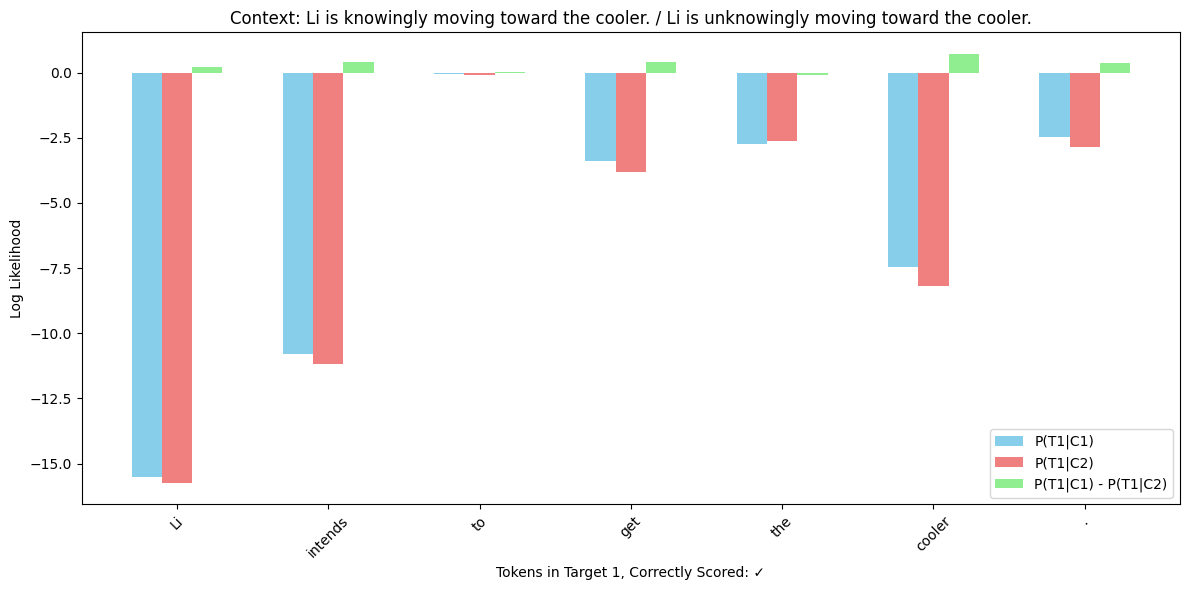

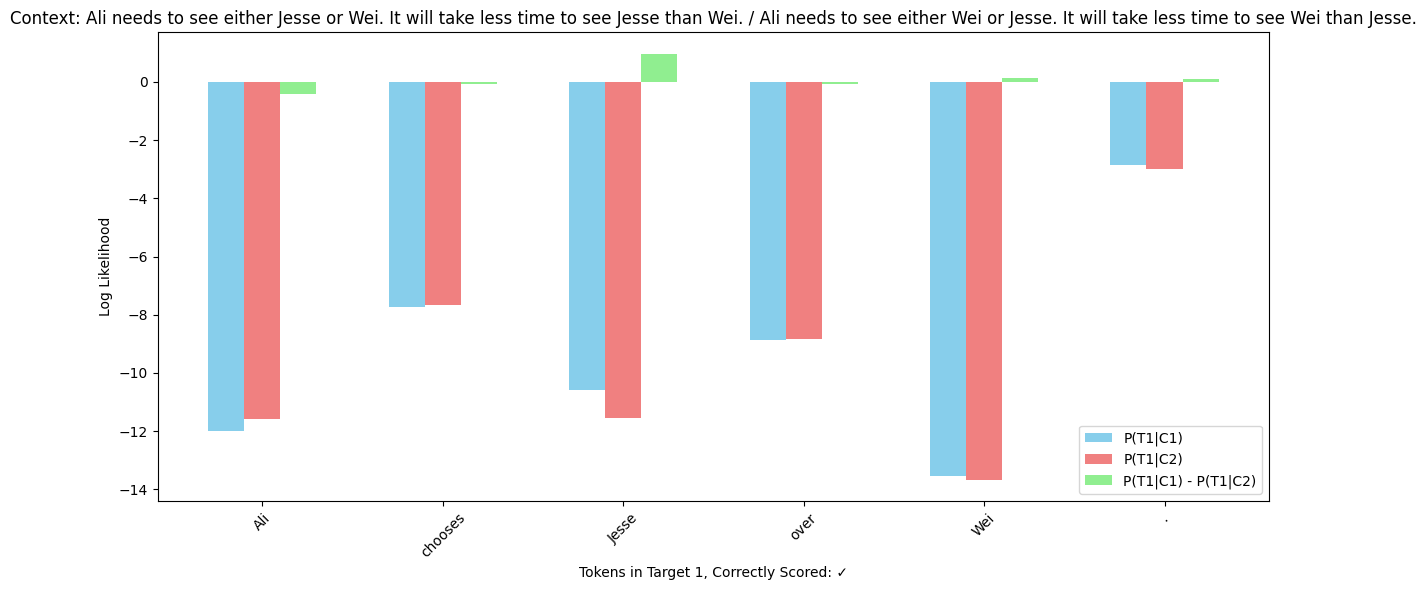

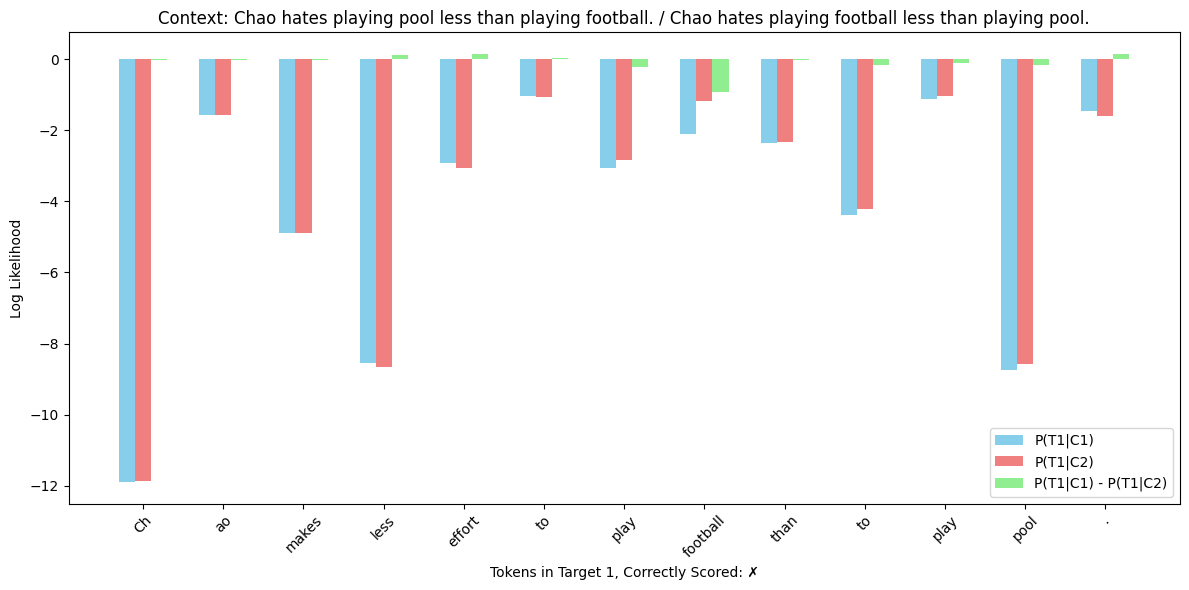

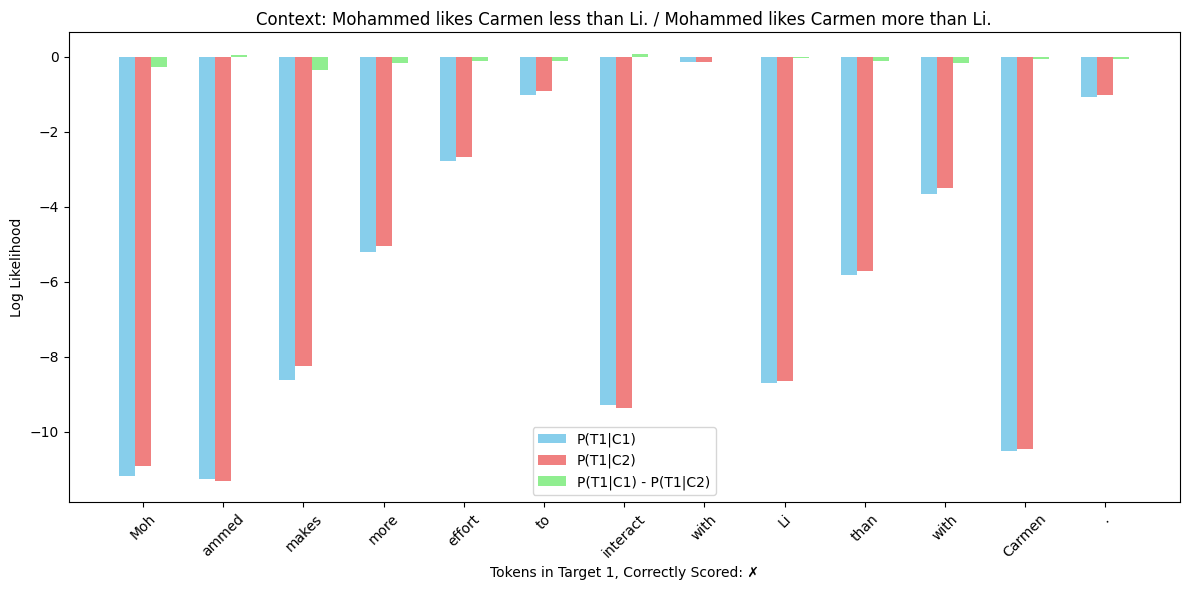

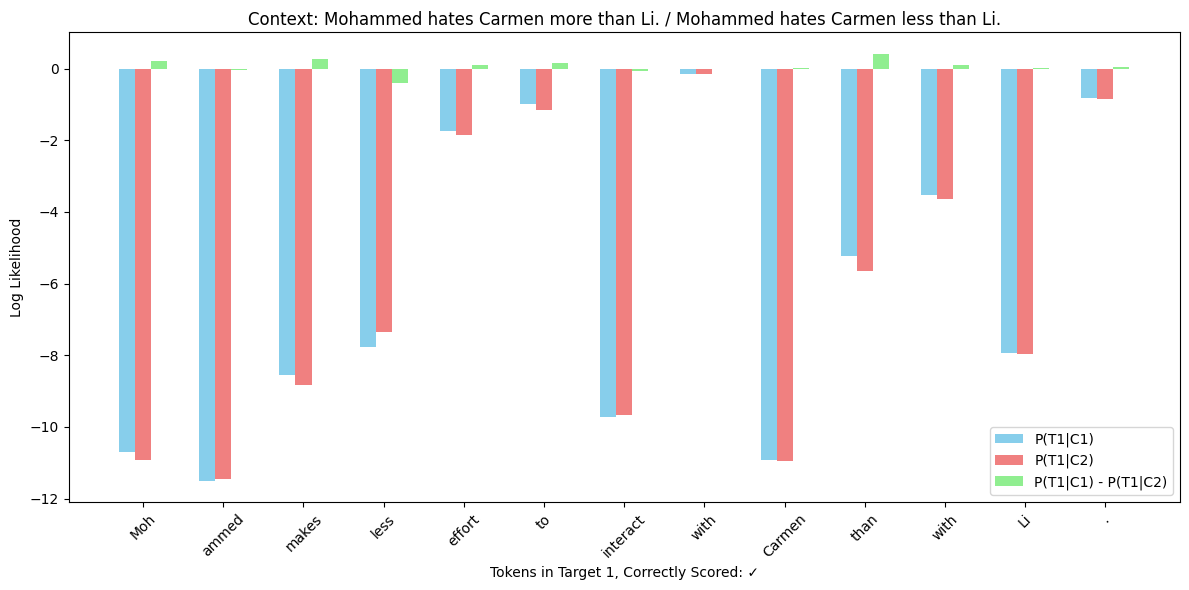

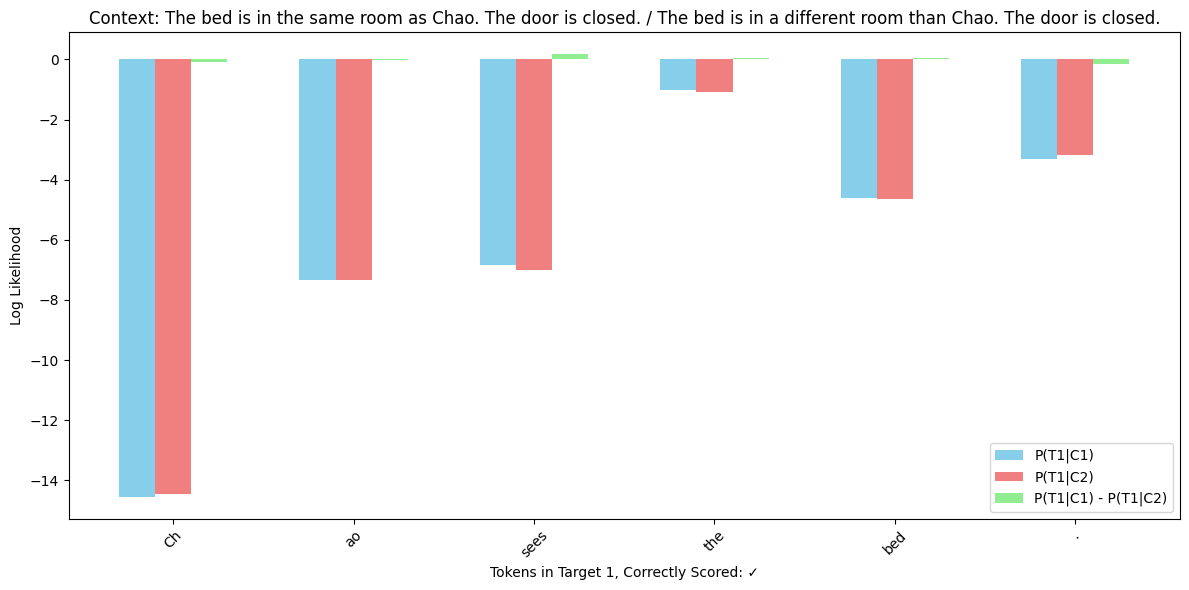

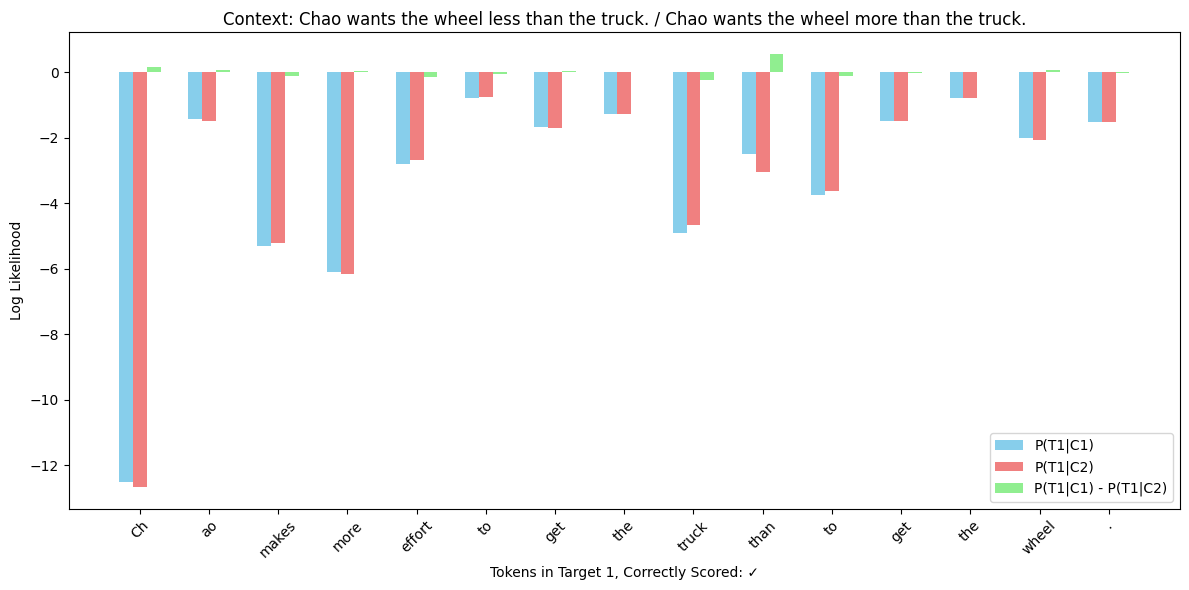

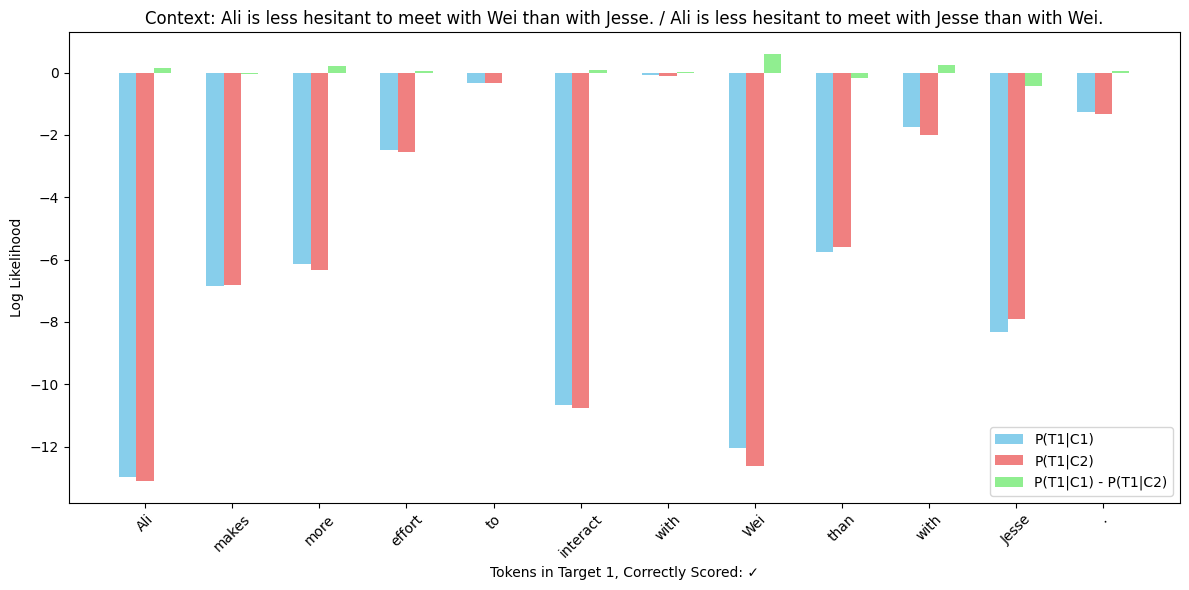

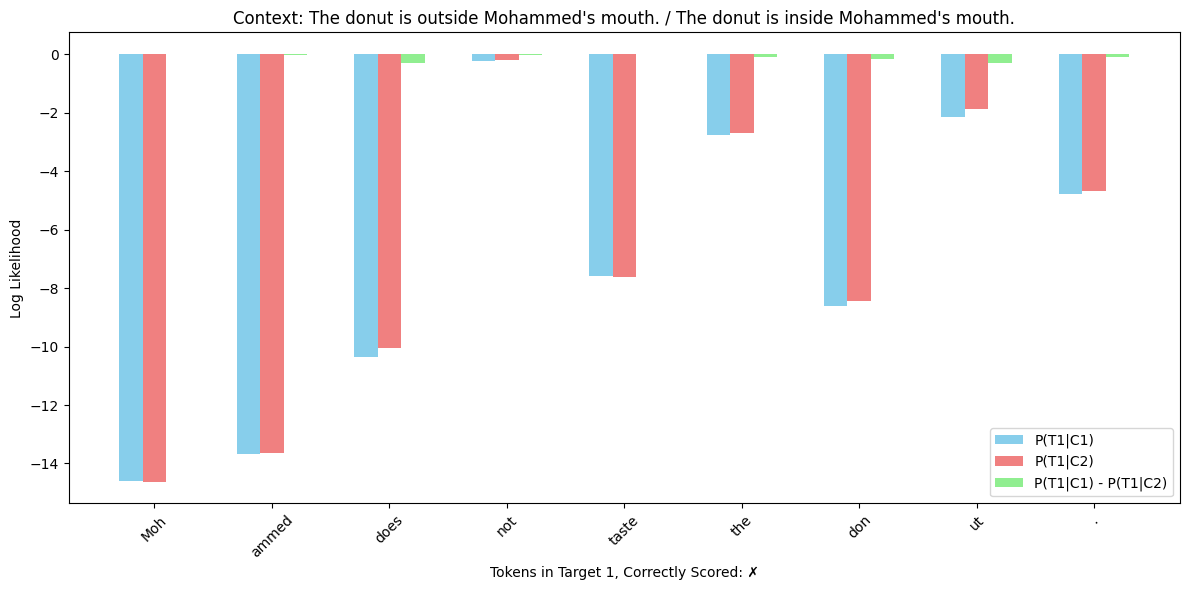

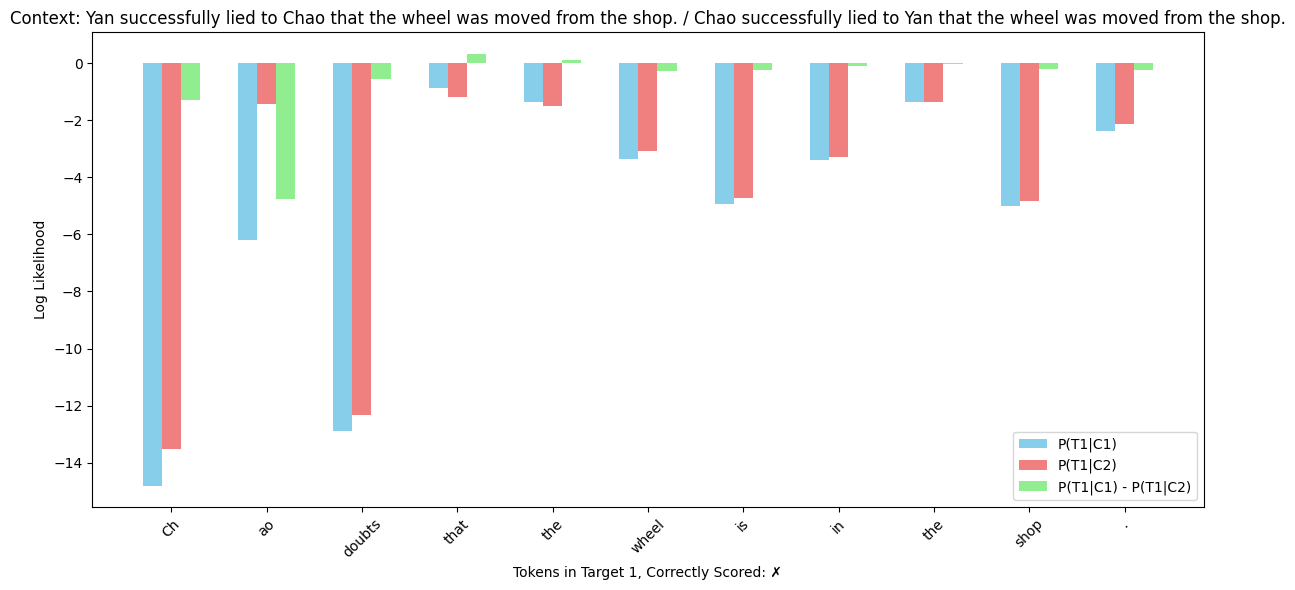

In [ ]:
#we randomly sample 5 examples in the highest performing domain
#and take a look at the per token log likelihoods
#we plot the per token log likelihoods for each target given each context
import random
import matplotlib.pyplot as plt
highest_domain = max_domain_value_pair[0]
highest_domain = 'agent-properties'
highest_domain_df = ewok_df[ewok_df['Domain'] == highest_domain]
sampled_df = highest_domain_df.sample(n=10, random_state=42)
for index, row in sampled_df.iterrows():
    context_1 = row['Context1']
    context_2 = row['Context2']
    target_1 = row['Target1']
    target_2 = row['Target2']
    #we tokenize the target sentences
    #they will be used as x axis labels
    target_1_tokens = tokenizer.tokenize(target_1)
    #we get rid of the special G characters in the tokenized output
    target_1_tokens = [token.replace('Ġ', '') for token in target_1_tokens]
    target_2_tokens = tokenizer.tokenize(target_2)
    target_2_tokens = [token.replace('Ġ', '') for token in target_2_tokens]
    #we compute conditional per token log likelihoods
    ptcll_c1_t1 = per_token_conditional_log_likelihood(model, tokenizer, [context_1], [target_1])[0].cpu().numpy()
    ptcll_c2_t1 = per_token_conditional_log_likelihood(model, tokenizer, [context_2], [target_1])[0].cpu().numpy()
    ptcll_c1_t2 = per_token_conditional_log_likelihood(model, tokenizer, [context_1], [target_2])[0].cpu().numpy()
    ptcll_c2_t2 = per_token_conditional_log_likelihood(model, tokenizer, [context_2], [target_2])[0].cpu().numpy()
    #we score the targets if perform given the correct context vs the incorrect context
    t1_score = np.sum(ptcll_c1_t1) > np.sum(ptcll_c2_t1)
    t1_score = '✗' if t1_score == False else '✓'
    t2_score = np.sum(ptcll_c2_t2) > np.sum(ptcll_c1_t2)
    t2_score = '✗' if t2_score == False else '✓'
    #we plot the per token log likelihoods
    x1 = np.arange(len(target_1_tokens))
    x2 = np.arange(len(target_2_tokens))
    plt.figure(figsize=(12, 6))
    #we make a bar plot with P(T1|C1) and P(T1|C2) and P(T1|C1) - P(T1|C2)
    bar_width = 0.2
    plt.bar(x1 - bar_width, ptcll_c1_t1, width=bar_width, label='P(T1|C1)', color='skyblue')
    plt.bar(x1, ptcll_c2_t1, width=bar_width, label='P(T1|C2)', color='lightcoral')
    plt.bar(x1 + bar_width, ptcll_c1_t1 - ptcll_c2_t1, width=bar_width, label='P(T1|C1) - P(T1|C2)', color='lightgreen')
    plt.xticks(x1, target_1_tokens, rotation=45)
    plt.xlabel('Tokens in Target 1,' + ' Correctly Scored: ' + t1_score)
    plt.ylabel('Log Likelihood')
    plt.title('Context: ' + context_1 + ' / ' + context_2)
    plt.legend()
    plt.tight_layout()
    plt.show()

